<a href="https://colab.research.google.com/github/sharvani1357/BERT-model/blob/main/BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")


print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [8]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/resume-dataset
['Resume', 'data']


In [9]:
resume_folder = os.path.join(path, "Resume")

print(os.listdir(resume_folder)[:10])

['Resume.csv']


In [10]:
import os

print(os.listdir("/kaggle/input/resume-dataset/data"))
print(os.listdir("/kaggle/input/resume-dataset/data/data"))

['data']
['DESIGNER', 'BPO', 'FINANCE', 'CONSTRUCTION', 'SALES', 'AUTOMOBILE', 'CONSULTANT', 'CHEF', 'APPAREL', 'AGRICULTURE', 'TEACHER', 'HR', 'DIGITAL-MEDIA', 'ACCOUNTANT', 'HEALTHCARE', 'INFORMATION-TECHNOLOGY', 'ADVOCATE', 'FITNESS', 'AVIATION', 'PUBLIC-RELATIONS', 'ENGINEERING', 'BUSINESS-DEVELOPMENT', 'BANKING', 'ARTS']


In [11]:
import os

for root, dirs, files in os.walk("/kaggle/input/resume-dataset"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/resume-dataset/Resume/Resume.csv


In [12]:
# ==========================================
# TASK 1 : DATA PREPARATION
# ==========================================

import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------
# LOAD DATASET
# ------------------------------------------

df = pd.read_csv(
    "/kaggle/input/resume-dataset/Resume/Resume.csv"
)

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

# ------------------------------------------
# CLEANING FUNCTION
# ------------------------------------------

def clean_resume(text):

    text = str(text)

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Lowercase
    text = text.lower()

    # Remove special symbols
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# ------------------------------------------
# CLEAN RESUMES
# ------------------------------------------

df["clean_resume"] = df["Resume_str"].apply(
    clean_resume
)

# ------------------------------------------
# LABEL ENCODING
# ------------------------------------------

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["Category"]
)

# ------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_resume"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# ------------------------------------------
# OUTPUT
# ------------------------------------------

print("\nTraining Samples:", len(train_texts))
print("Testing Samples:", len(test_texts))
print("Number of Classes:", len(label_encoder.classes_))

print("\nSample Category:")
print(df["Category"].iloc[0])

print("\nSample Clean Resume:")
print(df["clean_resume"].iloc[0][:500])

Dataset Shape:
(2484, 4)

Columns:
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Training Samples: 1987
Testing Samples: 497
Number of Classes: 24

Sample Category:
HR

Sample Clean Resume:
hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missour


In [13]:
# ==========================================
# TASK 2 : BERT TOKENIZATION
# ==========================================

from transformers import BertTokenizer

# ------------------------------------------
# LOAD TOKENIZER
# ------------------------------------------

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

# ------------------------------------------
# SAMPLE RESUME
# ------------------------------------------

sample_text = train_texts.iloc[0]

print("Original Resume Text:\n")
print(sample_text[:300])

# ------------------------------------------
# TOKENIZATION
# ------------------------------------------

tokens = tokenizer.tokenize(
    sample_text
)

# ------------------------------------------
# ADD SPECIAL TOKENS
# ------------------------------------------

bert_tokens = (
    ["[CLS]"]
    +
    tokens
    +
    ["[SEP]"]
)

print("\nFirst 50 BERT Tokens:\n")
print(bert_tokens[:50])

# ------------------------------------------
# TOKEN IDS
# ------------------------------------------

token_ids = tokenizer.convert_tokens_to_ids(
    bert_tokens
)

print("\nFirst 50 Token IDs:\n")
print(token_ids[:50])

# ------------------------------------------
# COMPLETE ENCODING
# ------------------------------------------

encoded = tokenizer(
    sample_text,
    add_special_tokens=True,
    max_length=128,
    truncation=True,
    padding="max_length",
    return_attention_mask=True,
    return_tensors="pt"
)

print("\nInput IDs Shape:")
print(encoded["input_ids"].shape)

print("\nAttention Mask Shape:")
print(encoded["attention_mask"].shape)

print("\nFirst 20 Input IDs:")
print(encoded["input_ids"][0][:20])

print("\nFirst 20 Attention Mask Values:")
print(encoded["attention_mask"][0][:20])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (778 > 512). Running this sequence through the model will result in indexing errors


Original Resume Text:

hr coordinator summary from my first job as a retail salesperson i had a passion for leadership and the development of others as a human resources professional i have had the privilege of working with new staff members to help them be successful in the organization my human resources experience is c

First 50 BERT Tokens:

['[CLS]', 'hr', 'coordinator', 'summary', 'from', 'my', 'first', 'job', 'as', 'a', 'retail', 'sales', '##person', 'i', 'had', 'a', 'passion', 'for', 'leadership', 'and', 'the', 'development', 'of', 'others', 'as', 'a', 'human', 'resources', 'professional', 'i', 'have', 'had', 'the', 'privilege', 'of', 'working', 'with', 'new', 'staff', 'members', 'to', 'help', 'them', 'be', 'successful', 'in', 'the', 'organization', 'my', 'human']

First 50 Token IDs:

[101, 17850, 10669, 12654, 2013, 2026, 2034, 3105, 2004, 1037, 7027, 4341, 27576, 1045, 2018, 1037, 6896, 2005, 4105, 1998, 1996, 2458, 1997, 2500, 2004, 1037, 2529, 4219, 2658, 1045, 2031, 2018,

In [14]:
# ==========================================
# TASK 3 : INPUT EMBEDDINGS
# ==========================================

import torch
from transformers import BertModel

# ------------------------------------------
# LOAD PRETRAINED BERT
# ------------------------------------------

bert = BertModel.from_pretrained(
    "bert-base-uncased"
)

# ------------------------------------------
# SAMPLE RESUME
# ------------------------------------------

sample_text = train_texts.iloc[0]

# ------------------------------------------
# TOKENIZE INPUT
# ------------------------------------------

inputs = tokenizer(
    sample_text,
    max_length=128,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

# ------------------------------------------
# INPUT IDS
# ------------------------------------------

input_ids = inputs["input_ids"]

# ------------------------------------------
# TOKEN EMBEDDINGS
# ------------------------------------------

token_embeddings = \
bert.embeddings.word_embeddings(
    input_ids
)

print("Token Embedding Shape:")
print(token_embeddings.shape)

# ------------------------------------------
# POSITION IDS
# ------------------------------------------

seq_length = input_ids.size(1)

position_ids = torch.arange(
    seq_length
).unsqueeze(0)

# ------------------------------------------
# POSITION EMBEDDINGS
# ------------------------------------------

position_embeddings = \
bert.embeddings.position_embeddings(
    position_ids
)

print("\nPosition Embedding Shape:")
print(position_embeddings.shape)

# ------------------------------------------
# SEGMENT IDS
# ------------------------------------------

segment_ids = inputs["token_type_ids"]

# ------------------------------------------
# SEGMENT EMBEDDINGS
# ------------------------------------------

segment_embeddings = \
bert.embeddings.token_type_embeddings(
    segment_ids
)

print("\nSegment Embedding Shape:")
print(segment_embeddings.shape)

# ------------------------------------------
# FINAL BERT INPUT
# ------------------------------------------

final_embeddings = (
    token_embeddings
    +
    position_embeddings
    +
    segment_embeddings
)

print("\nFinal Embedding Shape:")
print(final_embeddings.shape)

# ------------------------------------------
# DISPLAY SAMPLE VALUES
# ------------------------------------------

print("\nToken Embedding (First 10 Values):")
print(token_embeddings[0][0][:10])

print("\nPosition Embedding (First 10 Values):")
print(position_embeddings[0][0][:10])

print("\nSegment Embedding (First 10 Values):")
print(segment_embeddings[0][0][:10])

print("\nFinal Input Embedding (First 10 Values):")
print(final_embeddings[0][0][:10])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Token Embedding Shape:
torch.Size([1, 128, 768])

Position Embedding Shape:
torch.Size([1, 128, 768])

Segment Embedding Shape:
torch.Size([1, 128, 768])

Final Embedding Shape:
torch.Size([1, 128, 768])

Token Embedding (First 10 Values):
tensor([ 0.0136, -0.0265, -0.0235, -0.0078,  0.0086, -0.0077, -0.0099,  0.0060,
         0.0047, -0.0310], grad_fn=<SliceBackward0>)

Position Embedding (First 10 Values):
tensor([ 0.0175, -0.0256, -0.0366, -0.0253,  0.0080, -0.0204, -0.0038, -0.0047,
         0.0062, -0.0383], grad_fn=<SliceBackward0>)

Segment Embedding (First 10 Values):
tensor([ 0.0004,  0.0110,  0.0037,  0.0015,  0.0006, -0.0109,  0.0087, -0.0038,
        -0.0075,  0.0150], grad_fn=<SliceBackward0>)

Final Input Embedding (First 10 Values):
tensor([ 0.0316, -0.0411, -0.0564, -0.0316,  0.0171, -0.0389, -0.0050, -0.0024,
         0.0034, -0.0543], grad_fn=<SliceBackward0>)


In [15]:
# ==========================================
# TASK 4 : POSITIONAL EMBEDDINGS
# ==========================================

import torch
import pandas as pd

# ------------------------------------------
# SAMPLE RESUME
# ------------------------------------------

sample_text = train_texts.iloc[0]

# ------------------------------------------
# TOKENIZE
# ------------------------------------------

inputs = tokenizer(
    sample_text,
    max_length=20,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

input_ids = inputs["input_ids"]

# ------------------------------------------
# CONVERT IDS TO TOKENS
# ------------------------------------------

tokens = tokenizer.convert_ids_to_tokens(
    input_ids[0]
)

# ------------------------------------------
# POSITION IDS
# ------------------------------------------

seq_length = input_ids.size(1)

position_ids = torch.arange(
    seq_length
)

# ------------------------------------------
# POSITION EMBEDDINGS
# ------------------------------------------

position_embeddings = \
bert.embeddings.position_embeddings(
    position_ids
)

# ------------------------------------------
# DISPLAY TABLE
# ------------------------------------------

data = []

for i in range(len(tokens)):

    data.append([
        tokens[i],
        int(position_ids[i]),
        position_embeddings[i][:5].tolist()
    ])

position_df = pd.DataFrame(
    data,
    columns=[
        "Word",
        "Position",
        "Embedding(first 5 values)"
    ]
)

print(position_df)

           Word  Position                          Embedding(first 5 values)
0         [CLS]         0  [0.017505383118987083, -0.025631008669734, -0....
1            hr         1  [0.007758042309433222, 0.002261300105601549, -...
2   coordinator         2  [-0.011287464760243893, -0.0019644140265882015...
3       summary         3  [-0.004194893408566713, -0.011852281168103218,...
4          from         4  [-0.005608681123703718, -0.010445193387567997,...
5            my         5  [-0.003087107092142105, -0.018956413492560387,...
6         first         6  [0.0064256698824465275, -0.017664296552538872,...
7           job         7  [0.000626129622105509, -0.016088562086224556, ...
8            as         8  [0.00203499523922801, -0.014568672515451908, -...
9             a         9  [0.006440211087465286, -0.003360082395374775, ...
10       retail        10  [-0.00962081179022789, -0.0021375392097979784,...
11        sales        11  [-0.011239342391490936, 0.00412750942632556, -...

In [16]:
# ==========================================
# TASK 5 : SEGMENT EMBEDDINGS
# ==========================================

import torch
import pandas as pd

# ------------------------------------------
# SENTENCE A
# ------------------------------------------

sentence_a = "I know Python"

# ------------------------------------------
# SENTENCE B
# ------------------------------------------

sentence_b = "I know TensorFlow"

# ------------------------------------------
# TOKENIZE SENTENCE PAIR
# ------------------------------------------

inputs = tokenizer(
    sentence_a,
    sentence_b,
    return_tensors="pt"
)

# ------------------------------------------
# INPUT IDS
# ------------------------------------------

input_ids = inputs["input_ids"]

# ------------------------------------------
# TOKENS
# ------------------------------------------

tokens = tokenizer.convert_ids_to_tokens(
    input_ids[0]
)

# ------------------------------------------
# SEGMENT IDS
# ------------------------------------------

segment_ids = inputs["token_type_ids"][0]

# ------------------------------------------
# SEGMENT EMBEDDINGS
# ------------------------------------------

segment_embeddings = \
bert.embeddings.token_type_embeddings(
    inputs["token_type_ids"]
)

# ------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------

data = []

for i in range(len(tokens)):

    data.append([
        tokens[i],
        int(segment_ids[i]),
        segment_embeddings[0][i][:5].tolist()
    ])

segment_df = pd.DataFrame(
    data,
    columns=[
        "Token",
        "Segment ID",
        "Embedding (First 5 Values)"
    ]
)

print(segment_df)

    Token  Segment ID                         Embedding (First 5 Values)
0   [CLS]           0  [0.00043164269300177693, 0.010988255962729454,...
1       i           0  [0.00043164269300177693, 0.010988255962729454,...
2    know           0  [0.00043164269300177693, 0.010988255962729454,...
3  python           0  [0.00043164269300177693, 0.010988255962729454,...
4   [SEP]           0  [0.00043164269300177693, 0.010988255962729454,...
5       i           1  [0.001113191363401711, -0.002991687273606658, ...
6    know           1  [0.001113191363401711, -0.002991687273606658, ...
7  tensor           1  [0.001113191363401711, -0.002991687273606658, ...
8  ##flow           1  [0.001113191363401711, -0.002991687273606658, ...
9   [SEP]           1  [0.001113191363401711, -0.002991687273606658, ...


In [17]:
# ==========================================
# TASK 6 : TRANSFORMER ENCODER LAYERS
# ==========================================

import torch
from transformers import BertModel

# ------------------------------------------
# LOAD BERT MODEL
# ------------------------------------------

bert = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True,
    output_hidden_states=True
)

# ------------------------------------------
# SAMPLE RESUME
# ------------------------------------------

sample_text = train_texts.iloc[0]

# ------------------------------------------
# TOKENIZE
# ------------------------------------------

inputs = tokenizer(
    sample_text,
    max_length=128,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

# ------------------------------------------
# FORWARD PASS
# ------------------------------------------

with torch.no_grad():

    outputs = bert(**inputs)

# ------------------------------------------
# HIDDEN STATES
# ------------------------------------------

hidden_states = outputs.hidden_states

# ------------------------------------------
# ATTENTION WEIGHTS
# ------------------------------------------

attentions = outputs.attentions

# ------------------------------------------
# FIRST ENCODER LAYER
# ------------------------------------------

layer_0_output = hidden_states[1]

layer_0_attention = attentions[0]

# ------------------------------------------
# SHAPES
# ------------------------------------------

print("Layer 0 Output Shape:")
print(layer_0_output.shape)

print("\nLayer 0 Attention Shape:")
print(layer_0_attention.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Layer 0 Output Shape:
torch.Size([1, 128, 768])

Layer 0 Attention Shape:
torch.Size([1, 12, 128, 128])


In [18]:
# ==========================================
# TASK 7 : BIDIRECTIONAL CONTEXT
# ==========================================

import torch
from transformers import BertTokenizer, BertModel

# ------------------------------------------
# LOAD TOKENIZER & MODEL
# ------------------------------------------

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

model = BertModel.from_pretrained(
    "bert-base-uncased"
)

# ------------------------------------------
# SENTENCES
# ------------------------------------------

sentence1 = \
"I went to the bank to deposit money."

sentence2 = \
"I sat near the bank of the river."

# ------------------------------------------
# TOKENIZE
# ------------------------------------------

inputs1 = tokenizer(
    sentence1,
    return_tensors="pt"
)

inputs2 = tokenizer(
    sentence2,
    return_tensors="pt"
)

# ------------------------------------------
# BERT OUTPUTS
# ------------------------------------------

with torch.no_grad():

    output1 = model(**inputs1)

    output2 = model(**inputs2)

# ------------------------------------------
# TOKENS
# ------------------------------------------

tokens1 = tokenizer.convert_ids_to_tokens(
    inputs1["input_ids"][0]
)

tokens2 = tokenizer.convert_ids_to_tokens(
    inputs2["input_ids"][0]
)

# ------------------------------------------
# FIND BANK POSITION
# ------------------------------------------

bank_pos1 = tokens1.index("bank")

bank_pos2 = tokens2.index("bank")

# ------------------------------------------
# CONTEXTUAL EMBEDDINGS
# ------------------------------------------

bank_vector1 = \
output1.last_hidden_state[
    0,
    bank_pos1
]

bank_vector2 = \
output2.last_hidden_state[
    0,
    bank_pos2
]

# ------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------

print("Sentence 1:")
print(sentence1)

print("\nBank Vector Shape:")
print(bank_vector1.shape)

print("\nFirst 10 Values:")
print(bank_vector1[:10])

print("\n" + "="*60)

print("\nSentence 2:")
print(sentence2)

print("\nBank Vector Shape:")
print(bank_vector2.shape)

print("\nFirst 10 Values:")
print(bank_vector2[:10])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence 1:
I went to the bank to deposit money.

Bank Vector Shape:
torch.Size([768])

First 10 Values:
tensor([ 0.7091, -0.2590, -0.0186, -0.0936,  1.2637,  0.0223, -0.3096,  0.9714,
        -0.1028,  0.2012])


Sentence 2:
I sat near the bank of the river.

Bank Vector Shape:
torch.Size([768])

First 10 Values:
tensor([-0.1625, -0.5113, -0.2257, -0.0098, -0.5744, -0.0777,  0.1123,  1.9982,
         0.0955, -0.4773])


In [19]:
# ==========================================
# TASK 8 : MASKED LANGUAGE MODELING (MLM)
# ==========================================

from transformers import pipeline

# ------------------------------------------
# LOAD MLM PIPELINE
# ------------------------------------------

fill_mask = pipeline(
    "fill-mask",
    model="bert-base-uncased"
)

# ------------------------------------------
# EXAMPLE SENTENCE
# ------------------------------------------

text = "I love [MASK] learning"

# ------------------------------------------
# PREDICTIONS
# ------------------------------------------

predictions = fill_mask(text)

# ------------------------------------------
# DISPLAY TOP 5
# ------------------------------------------

print("Input Sentence:")
print(text)

print("\nTop 5 Predictions:\n")

for i, pred in enumerate(predictions, start=1):

    print(f"Rank {i}")

    print(
        "Predicted Word:",
        pred["token_str"]
    )

    print(
        "Probability:",
        round(pred["score"], 4)
    )

    print(
        "Completed Sentence:",
        pred["sequence"]
    )

    print("-" * 50)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Input Sentence:
I love [MASK] learning

Top 5 Predictions:

Rank 1
Predicted Word: his
Probability: 0.0932
Completed Sentence: i love his learning
--------------------------------------------------
Rank 2
Predicted Word: just
Probability: 0.0928
Completed Sentence: i love just learning
--------------------------------------------------
Rank 3
Predicted Word: her
Probability: 0.087
Completed Sentence: i love her learning
--------------------------------------------------
Rank 4
Predicted Word: about
Probability: 0.0784
Completed Sentence: i love about learning
--------------------------------------------------
Rank 5
Predicted Word: the
Probability: 0.071
Completed Sentence: i love the learning
--------------------------------------------------


In [20]:
# ==========================================
# TASK 9 : NEXT SENTENCE PREDICTION
# ==========================================

from transformers import BertTokenizer

# ------------------------------------------
# SENTENCE PAIRS
# ------------------------------------------

sentence_a = \
"I love machine learning."

sentence_b = \
"Transformers are powerful."

# ------------------------------------------
# TOKENIZE PAIR
# ------------------------------------------

inputs = tokenizer(
    sentence_a,
    sentence_b,
    return_tensors="pt"
)

# ------------------------------------------
# DISPLAY TOKENS
# ------------------------------------------

tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

print("BERT Input Tokens:\n")

print(tokens)

print("\nToken Type IDs:\n")

print(inputs["token_type_ids"])

BERT Input Tokens:

['[CLS]', 'i', 'love', 'machine', 'learning', '.', '[SEP]', 'transformers', 'are', 'powerful', '.', '[SEP]']

Token Type IDs:

tensor([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]])


In [21]:
!pip install transformers datasets -q

In [22]:
# ==========================================
# TASK 10 : FINE-TUNE BERT FOR
# RESUME CLASSIFICATION
# ==========================================

import torch
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# ------------------------------------------
# LOAD TOKENIZER
# ------------------------------------------

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

# ------------------------------------------
# TOKENIZE TRAIN DATA
# ------------------------------------------

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

# ------------------------------------------
# TOKENIZE TEST DATA
# ------------------------------------------

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

# ------------------------------------------
# DATASET CLASS
# ------------------------------------------

class ResumeDataset(torch.utils.data.Dataset):

    def __init__(
            self,
            encodings,
            labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(
            self,
            idx):

        item = {
            key: torch.tensor(val[idx])

            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            int(self.labels.iloc[idx])
        )

        return item

    def __len__(self):

        return len(self.labels)

# ------------------------------------------
# CREATE DATASETS
# ------------------------------------------

train_dataset = ResumeDataset(
    train_encodings,
    train_labels
)

test_dataset = ResumeDataset(
    test_encodings,
    test_labels
)

# ------------------------------------------
# NUMBER OF CLASSES
# ------------------------------------------

num_classes = len(
    label_encoder.classes_
)

print(
    "Number of Categories:",
    num_classes
)

# ------------------------------------------
# LOAD BERT CLASSIFIER
# ------------------------------------------

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_classes
)

print(
    "\nBERT Model Loaded Successfully"
)

# ------------------------------------------
# TRAINING ARGUMENTS
# ------------------------------------------

training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    logging_steps=50,

    save_steps=500,

    report_to="none"
)

# ------------------------------------------
# TRAINER
# ------------------------------------------

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

print("\nTraining Started...\n")

trainer.train()

# ------------------------------------------
# EVALUATE MODEL
# ------------------------------------------

print("\nEvaluating Model...\n")

results = trainer.evaluate()

print("\nEvaluation Results:")

for key, value in results.items():

    print(
        f"{key} : {value}"
    )

# ------------------------------------------
# SAVE MODEL
# ------------------------------------------

trainer.save_model(
    "./resume_classifier"
)

tokenizer.save_pretrained(
    "./resume_classifier"
)

print(
    "\nModel Saved Successfully"
)

Number of Categories: 24


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT Model Loaded Successfully

Training Started...



Step,Training Loss
50,3.210492
100,3.147833
150,2.823047
200,2.182303
250,1.633827
300,1.244816
350,1.022205
400,0.970865
450,0.949056
500,0.919987


...


Evaluating Model...



Training Loss,Validation Loss,Step
0.660239,0.730680,747



Evaluation Results:
eval_loss : 0.7306804656982422


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model Saved Successfully


In [23]:
# ==========================================
# TASK 11 : MODEL EVALUATION
# ==========================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------
# GET PREDICTIONS
# ------------------------------------------

predictions = trainer.predict(
    test_dataset
)

# ------------------------------------------
# PREDICTED LABELS
# ------------------------------------------

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

# ------------------------------------------
# TRUE LABELS
# ------------------------------------------

y_true = test_labels.values

# ------------------------------------------
# ACCURACY
# ------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

# ------------------------------------------
# PRECISION
# ------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

# ------------------------------------------
# RECALL
# ------------------------------------------

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

# ------------------------------------------
# F1 SCORE
# ------------------------------------------

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# ------------------------------------------
# RESULTS
# ------------------------------------------

print("="*50)

print("ACCURACY :", round(accuracy,4))

print("PRECISION:", round(precision,4))

print("RECALL   :", round(recall,4))

print("F1 SCORE :", round(f1,4))

print("="*50)

# ------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# ------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:\n")

print(cm)

ACCURACY : 0.8229
PRECISION: 0.8043
RECALL   : 0.8229
F1 SCORE : 0.8114

Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       1.00      1.00      1.00        24
              ADVOCATE       0.80      0.83      0.82        24
           AGRICULTURE       0.89      0.62      0.73        13
               APPAREL       0.42      0.42      0.42        19
                  ARTS       0.62      0.62      0.62        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.76      0.79      0.78        24
               BANKING       0.67      0.70      0.68        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.89      1.00      0.94        24
                  CHEF       0.91      0.83      0.87        24
          CONSTRUCTION       0.95      0.95      0.95        22
            CONSULTANT       0.92      0.96      0.94        23
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

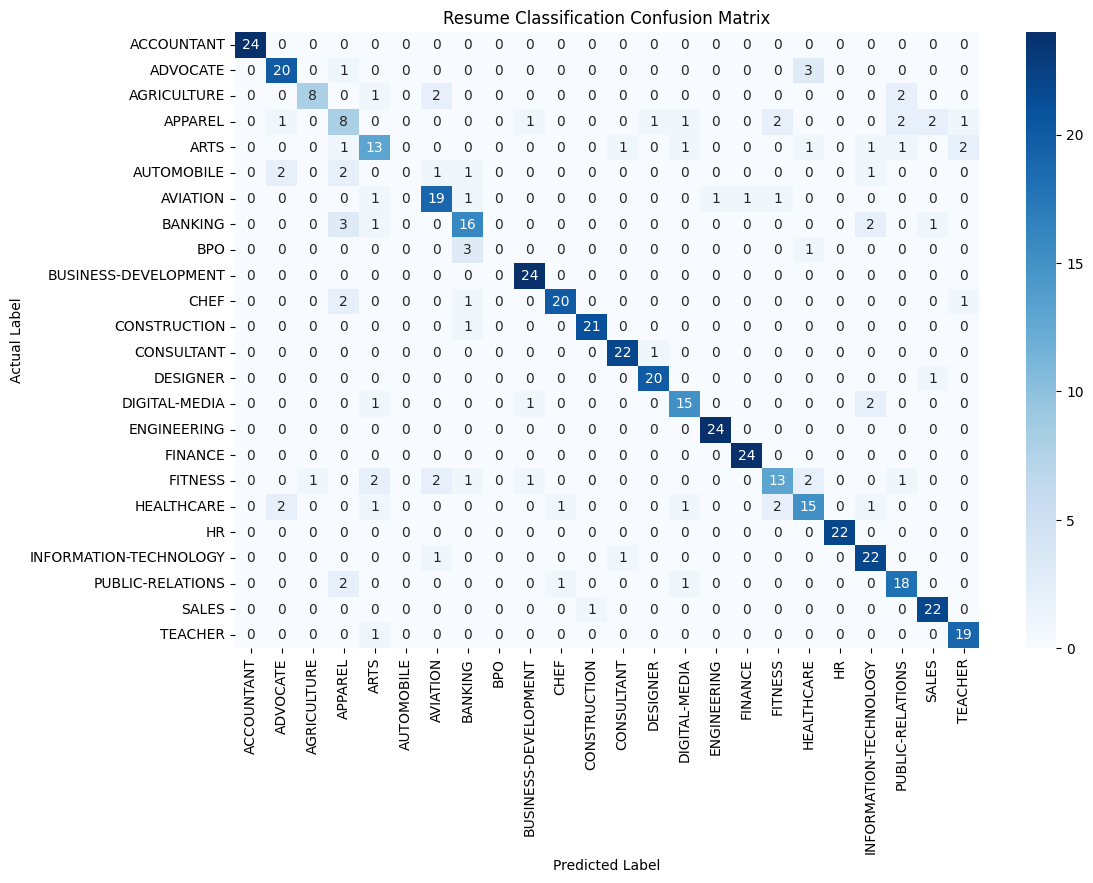

In [24]:
# ==========================================
# CONFUSION MATRIX HEATMAP
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Resume Classification Confusion Matrix")

plt.show()

In [25]:
# ==========================================
# TASK 12 : RESUME PREDICTION SYSTEM
# ==========================================

import torch

# ------------------------------------------
# DEVICE
# ------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

print("Using Device:", device)

# ------------------------------------------
# PREDICTION FUNCTION
# ------------------------------------------

def predict_resume_category(resume_text):

    model.eval()

    encoding = tokenizer(
        resume_text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    # Move tensors to model device
    encoding = {
        key: value.to(device)
        for key, value in encoding.items()
    }

    with torch.no_grad():

        outputs = model(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )

    logits = outputs.logits

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = torch.max(
        probabilities
    ).item()

    predicted_category = \
    label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    return (
        predicted_category,
        confidence
    )

# ------------------------------------------
# SAMPLE RESUME
# ------------------------------------------

resume_text = """
Experienced Data Scientist with Python,
TensorFlow, Deep Learning,
Machine Learning, NLP and
Predictive Analytics projects.
"""

# ------------------------------------------
# PREDICT
# ------------------------------------------

category, confidence = \
predict_resume_category(
    resume_text
)

print("\nResume Text:")
print(resume_text)

print("\nPredicted Category:")
print(category)

print(
    "\nConfidence:",
    round(confidence * 100, 2),
    "%"
)

Using Device: cuda

Resume Text:

Experienced Data Scientist with Python,
TensorFlow, Deep Learning,
Machine Learning, NLP and
Predictive Analytics projects.


Predicted Category:
INFORMATION-TECHNOLOGY

Confidence: 25.13 %
